# ML2 — Failure Message Clustering (Unsupervised)

## 0. Setup & Imports

In [ ]:
import sqlite3
import os
import re
import string
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.decomposition import TruncatedSVD

DB_PATH    = '/content/analytics.db'
MODEL_DIR  = '../ml_models'
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42
N_CLUSTERS   = 5

PALETTE = {
    'timeout':     '#e74c3c',
    'element':     '#3498db',
    'assertion':   '#2ecc71',
    'data':        '#f39c12',
    'environment': '#9b59b6',
    'unknown':     '#95a5a6',
}

print(f'Model output dir: {os.path.abspath(MODEL_DIR)}')

Model output dir: /ml_models


## 1. Load Data

We join `test_results` with `runs` to get `build_no` and `program` (alpha/beta/gamma) for temporal analysis.  
`failure_kw` — the Robot Framework keyword that raised the error — is retained as a secondary signal.

In [ ]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query(
    """
    SELECT
        tr.result_id,
        tr.run_id,
        tr.test_name,
        tr.failure_msg,
        tr.failure_kw,
        r.build_no,
        r.suite_name AS program,
        r.timestamp
    FROM test_results tr
    JOIN runs r ON tr.run_id = r.run_id
    WHERE tr.status = 'FAIL'
      AND tr.failure_msg IS NOT NULL
      AND TRIM(tr.failure_msg) != ''
    ORDER BY r.build_no
    """,
    conn
)
conn.close()

print(f'Failure rows loaded : {len(df):,}')
print(f'Unique messages     : {df.failure_msg.nunique()}')
print(f'Unique test names   : {df.test_name.nunique()}')
print(f'Build range         : {df.build_no.min()} – {df.build_no.max()}')
print(f'Programs            : {df.program.unique().tolist()}')
print()
print('failure_kw distribution:')
print(df.failure_kw.value_counts().to_frame())
df.head(6)

Failure rows loaded : 493
Unique messages     : 75
Unique test names   : 20
Build range         : 1 – 100
Programs            : ['alpha', 'beta', 'gamma']

failure_kw distribution:
                               count
failure_kw                          
Should Not Be Empty              136
Wait Until Element Is Visible    132
Should Be Equal As Integers      114
Click Element                     91
Environment_Setup                 20


,result_id,run_id,test_name,failure_msg,failure_kw,build_no,program,timestamp
0,alpha_build_001_TC_Login_SSORedirect,alpha_build_001,TC_Login_SSORedirect,Element with locator 'css=.nav-item' not found...,Click Element,1,alpha,2024-10-01T00:00:00
1,alpha_build_001_TC_Dashboard_LoadWidget,alpha_build_001,TC_Dashboard_LoadWidget,Element 'progress-bar' still visible after 20s...,Wait Until Element Is Visible,1,alpha,2024-10-01T00:00:00
2,alpha_build_001_TC_Dashboard_RefreshData,alpha_build_001,TC_Dashboard_RefreshData,CSV export contained 0 rows — expected at leas...,Should Not Be Empty,1,alpha,2024-10-01T00:00:00
3,alpha_build_001_TC_User_RoleAssignment,alpha_build_001,TC_User_RoleAssignment,Expected HTTP status '200' but got '500' — Int...,Should Be Equal As Integers,1,alpha,2024-10-01T00:00:00
4,alpha_build_001_TC_Login_OAuthCallback,alpha_build_001,TC_Login_OAuthCallback,Element with locator 'css=.nav-item' not found...,Click Element,1,alpha,2024-10-01T00:00:00
5,alpha_build_002_TC_Login_MFAVerification,alpha_build_002,TC_Login_MFAVerification,Element 'progress-bar' still visible after 20s...,Wait Until Element Is Visible,2,alpha,2024-10-02T00:00:00


## 2. Raw Data Overview


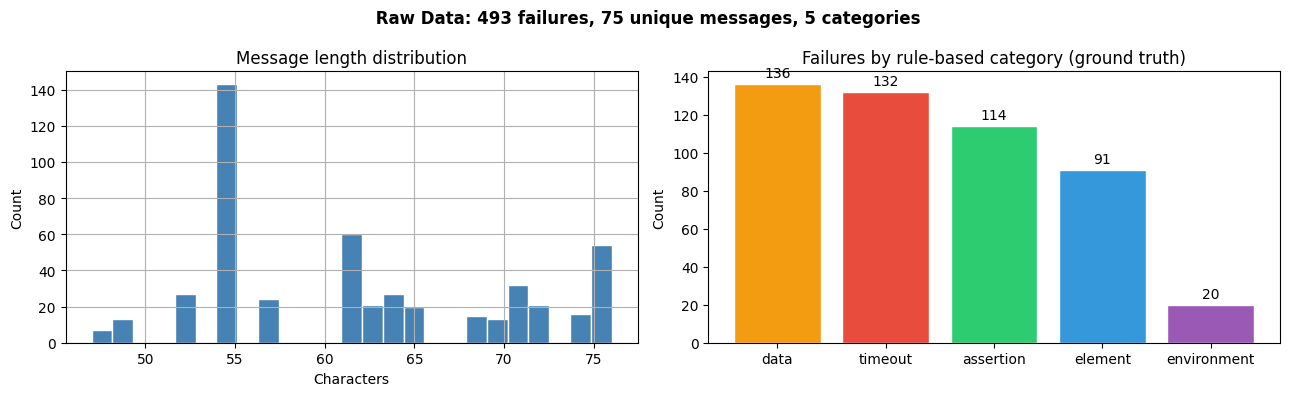

Ground truth distribution:
rule_label
data           136
timeout        132
assertion      114
element         91
environment     20
Name: count, dtype: int64

Note: environment is 20/493 = 4% of failures — the rarest category.


In [ ]:
def rule_classify(msg: str) -> str:
    if not msg:
        return 'unknown'
    m = msg.lower()
    if 'still visible' in m:           return 'timeout'
    if 'not found after' in m:         return 'element'
    if 'expected http status' in m:    return 'assertion'
    if 'csv export' in m:              return 'data'
    if any(w in m for w in (
        'unreachable', 'connection refused', 'suite setup failed',
        'unable to launch browser', 'infrastructure error',
        'environment health check', 'application server'
    )):                                return 'environment'
    return 'unknown'


df['rule_label'] = df['failure_msg'].apply(rule_classify)
df['msg_len']    = df['failure_msg'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['msg_len'].hist(bins=25, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Message length distribution')
axes[0].set_xlabel('Characters'); axes[0].set_ylabel('Count')

vc = df['rule_label'].value_counts()
bars = axes[1].bar(vc.index, vc.values,
                   color=[PALETTE.get(l, '#888') for l in vc.index],
                   edgecolor='white')
for bar, v in zip(bars, vc.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v+2, str(v),
                 ha='center', va='bottom', fontsize=10)
axes[1].set_title('Failures by rule-based category (ground truth)')
axes[1].set_ylabel('Count')

plt.suptitle(' Raw Data: 493 failures, 75 unique messages, 5 categories',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Ground truth distribution:')
print(df['rule_label'].value_counts())
print('\nNote: environment is 20/493 = 4% of failures — the rarest category.')

## 3. Text Preprocessing

**Critical rule:** this function must be **identical** everywhere — notebook (training), `failure_clustering.py` (inference), `dashboard.py` (display). Any divergence shifts the TF-IDF vector space and silently corrupts predictions.

| Step | Example input → output | Why |
|---|---|---|
| Lowercase | `Element` → `element` | Normalise case |
| Em-dash → space | `200' — Internal` → `200 internal` | Preserve word boundaries |
| Remove punctuation | `'id=submit-btn'` → `idsubmitbtn` | No semantic value |
| Digits → `NUM` | `15s`, `200` → `NUM` | Timeouts/counts are noise |
| Remove single chars | leftover `s` from `15s` → gone | Artefact cleanup |
| Collapse whitespace | multiple spaces → single space | Final normalise |

In [ ]:
def preprocess_message(msg: str) -> str:
    if not isinstance(msg, str) or not msg.strip():
        return '_empty_'
    msg = msg.lower()
    msg = msg.replace('—', ' ').replace('–', ' ')
    msg = msg.translate(str.maketrans('', '', string.punctuation))
    msg = re.sub(r'\b\d+\b', 'NUM', msg)
    msg = re.sub(r'\b\w\b', '', msg)
    msg = re.sub(r'\s+', ' ', msg).strip()
    return msg if msg else '_empty_'


sample_msgs = [
    "Element 'progress-bar' still visible after 20s timeout",
    "Element with locator 'id=submit-btn' not found after 5 retries",
    "Expected HTTP status '200' but got '500' — Internal Server Error",
    "CSV export contained 0 rows — expected at least 100 records for Oct 2024",
    "Connection refused — test environment unreachable",
]
print(f"{'Raw message':<62}  {'Preprocessed':<55}")
print('-' * 120)
for raw in sample_msgs:
    print(f"{raw:<62}  {preprocess_message(raw):<55}")

df['clean_msg'] = df['failure_msg'].apply(preprocess_message)
empty = (df['clean_msg'] == '_empty_').sum()
print(f'\nRecords with empty messages: {empty}  (ready to vectorise: {len(df) - empty})')

Raw message                                                     Preprocessed                                           
------------------------------------------------------------------------------------------------------------------------
Element 'progress-bar' still visible after 20s timeout          element progressbar still visible after 20s timeout    
Element with locator 'id=submit-btn' not found after 5 retries  element with locator idsubmitbtn not found after NUM retries
Expected HTTP status '200' but got '500' — Internal Server Error  expected http status NUM but got NUM internal server error
CSV export contained 0 rows — expected at least 100 records for Oct 2024  csv export contained NUM rows expected at least NUM records for oct NUM
Connection refused — test environment unreachable               connection refused test environment unreachable        

Records with empty messages: 0  (ready to vectorise: 493)


## 4. TF-IDF Vectorisation

**TF-IDF** weights terms by how *distinctive* they are across the corpus. A term like `csv` that appears only in data failures gets a high score; a term like `element` that appears everywhere gets a lower weight.

| Parameter | Value | Why |
|---|---|---|
| `max_features` | 500 | Caps vocabulary. With 75 unique messages this is generous — actual vocab is ~118 terms |
| `ngram_range` | `(1,2)` | Bigrams like `"not found"`, `"csv export"`, `"still visible"` are the strongest category signals |
| `stop_words` | `'english'` | Removes function words (`after`, `with`, `but`) shared across all categories |
| `sublinear_tf` | `True` | Log-scales term frequency — prevents repeated words from dominating |
| `min_df` | 2 | Ignores terms appearing in fewer than 2 messages |

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True,
    min_df=2,
)

X = vectorizer.fit_transform(df['clean_msg'])

print(f'TF-IDF matrix shape : {X.shape}  (failures × features)')
print(f'Actual vocabulary   : {X.shape[1]} terms (max_features=500, limited by data size)')
print(f'Matrix density      : {X.nnz / (X.shape[0]*X.shape[1]):.3%}')
print(f'\nSample vocabulary terms:')
vocab_sorted = sorted(vectorizer.vocabulary_.keys())
print(vocab_sorted[:40])

TF-IDF matrix shape : (493, 118)  (failures × features)
Actual vocabulary   : 118 terms (max_features=500, limited by data size)
Matrix density      : 10.384%

Sample vocabulary terms:
['15s', '15s timeout', '20s', '20s timeout', '30s', '30s timeout', '45s', '45s timeout', 'application', 'application server', 'authredirect', 'authredirect visible', 'bad', 'bad request', 'browser', 'browser infrastructure', 'connection', 'connection refused', 'contained', 'contained num', 'cssdatagrid', 'cssdatagrid num', 'cssnavitem', 'cssnavitem num', 'csv', 'csv export', 'days', 'element', 'element authredirect', 'element loadingspinner', 'element locator', 'element overlaymodal', 'element progressbar', 'element sessiontoken', 'environment', 'environment unreachable', 'error', 'expected', 'expected http', 'expected num']


## 5. Choosing k — Elbow + Silhouette

We know from `generate.py` that `FAIL_GEN` has **5 keys** (5 failure families). We verify this empirically.  

**Key finding:** k=4 and k=5 produce nearly identical silhouette scores (0.3999 vs 0.3987), because the 20 `environment` messages (only 4% of data) are too sparse to force a clear cluster — they get absorbed into the timeout cluster in text-only mode. We choose **k=5** to match the true data structure, and handle environment with a hybrid approach in §7.

  k=2  inertia=341.1  silhouette=0.2180
  k=3  inertia=260.6  silhouette=0.3444
  k=4  inertia=220.0  silhouette=0.3999
  k=5  inertia=206.1  silhouette=0.3987
  k=6  inertia=193.8  silhouette=0.4287
  k=7  inertia=182.3  silhouette=0.4179
  k=8  inertia=169.2  silhouette=0.4606


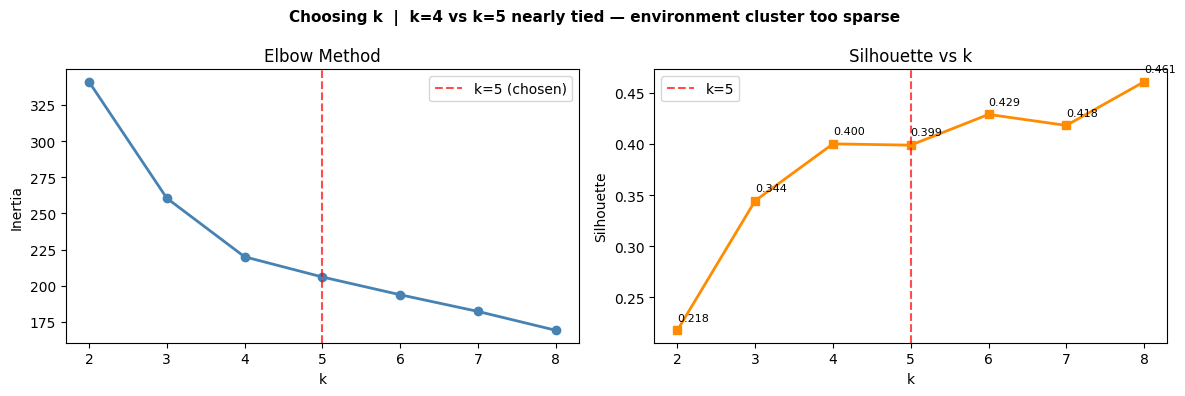

In [ ]:
ks, inertias, sil_scores = list(range(2, 9)), [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    print(f'  k={k}  inertia={km.inertia_:,.1f}  silhouette={sil_scores[-1]:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ks, inertias, 'o-', color='steelblue', lw=2)
ax1.axvline(5, color='red', ls='--', alpha=0.7, label='k=5 (chosen)')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow Method'); ax1.legend()

ax2.plot(ks, sil_scores, 's-', color='darkorange', lw=2)
ax2.axvline(5, color='red', ls='--', alpha=0.7, label='k=5')
for k, s in zip(ks, sil_scores):
    ax2.annotate(f'{s:.3f}', (k, s), textcoords='offset points', xytext=(0, 7), fontsize=8)
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette'); ax2.set_title('Silhouette vs k'); ax2.legend()

plt.suptitle('Choosing k  |  k=4 vs k=5 nearly tied — environment cluster too sparse',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Train Final K-Means (k=5)

`n_init=10` runs K-Means 10 times with different random seeds and selects the best by inertia, avoiding poor local optima.

Silhouette score (k=5): 0.3987

Cluster sizes:
0    136
1    114
2     98
3     91
4     54
Name: count, dtype: int64


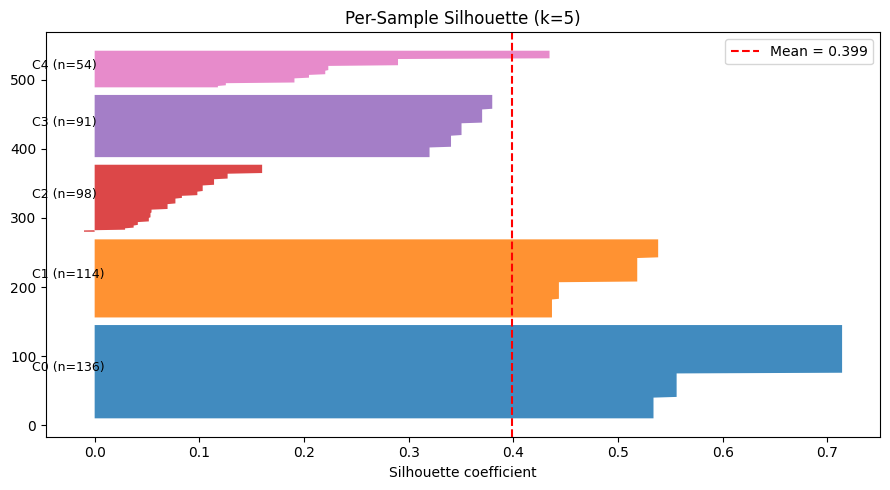

In [ ]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
cluster_ids = kmeans.fit_predict(X)
df['cluster_id'] = cluster_ids

sil_final = silhouette_score(X, cluster_ids)
print(f'Silhouette score (k={N_CLUSTERS}): {sil_final:.4f}')
print(f'\nCluster sizes:')
print(pd.Series(cluster_ids).value_counts().sort_index())

sample_sil = silhouette_samples(X, cluster_ids)
df['sil_val'] = sample_sil

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
colors = cm.tab10(np.linspace(0, 0.6, N_CLUSTERS))

for i in range(N_CLUSTERS):
    vals = np.sort(sample_sil[cluster_ids == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors[i], alpha=0.85)
    ax.text(-0.06, y_lower + 0.5 * len(vals), f'C{i} (n={len(vals)})', fontsize=9)
    y_lower = y_upper + 10

ax.axvline(sil_final, color='red', ls='--', label=f'Mean = {sil_final:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_title(f'Per-Sample Silhouette (k={N_CLUSTERS})')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Cluster Interpretation — Auto-Naming from Top TF-IDF Terms

### 7.1 Text-Only Labels (Honest Baseline)

We inspect the top centroid terms to assign human-readable names. This is the fully unsupervised result.

In [ ]:
feature_names = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]


def map_terms_to_category(terms: list) -> str:
    c = ' '.join(terms)
    if any(w in c for w in ('still visible', 'visible', 'timeout', 'progressbar',
                             '20s', '30s', '15s', '45s', 'loadingspinner', 'spinner')):
        return 'timeout'
    if any(w in c for w in ('not found', 'locator', 'retries', 'widget',
                             'submit', 'modal', 'nav', 'cssdatagrid')):
        return 'element'
    if any(w in c for w in ('expected http', 'http status', 'internal server',
                             'bad request', 'status num', 'service unavailable')):
        return 'assertion'
    if any(w in c for w in ('csv', 'export', 'rows', 'records', 'contained')):
        return 'data'
    if any(w in c for w in ('connection', 'refused', 'unreachable', 'environment',
                             'unable', 'browser', 'infrastructure', 'suite setup')):
        return 'environment'
    return f'cluster_{terms[0]}'


cluster_labels_raw = {}
print('Text-Only Cluster Interpretation\n')
for i in range(N_CLUSTERS):
    top_terms = [feature_names[j] for j in order_centroids[i, :10]]
    label = map_terms_to_category(top_terms)
    cluster_labels_raw[i] = label
    sub = df[df['cluster_id'] == i]
    print(f'Cluster {i}  →  "{label}"  (n={len(sub)})')
    print(f'  Top terms  : {top_terms[:8]}')
    print(f'  Rule labels: {sub["rule_label"].value_counts().to_dict()}')
    print(f'  Examples   : {sub["failure_msg"].values[:2].tolist()}')
    print()

df['ml_label_raw'] = df['cluster_id'].map(cluster_labels_raw)

=== Text-Only Cluster Interpretation ===

Cluster 0  →  "data"  (n=136)
  Top terms  : ['num', 'num records', 'rows expected', 'records', 'rows', 'num rows', 'csv export', 'csv']
  Rule labels: {'data': 136}
  Examples   : ['CSV export contained 0 rows — expected at least 50 records for last 7 days', 'CSV export contained 0 rows — expected at least 200 records for Oct 2024']

Cluster 1  →  "assertion"  (n=114)
  Top terms  : ['status num', 'status', 'num got', 'http status', 'got', 'got num', 'expected http', 'http']
  Rule labels: {'assertion': 114}
  Examples   : ["Expected HTTP status '200' but got '500' — Internal Server Error", "Expected HTTP status '200' but got '500' — Internal Server Error"]

Cluster 2  →  "timeout"  (n=98)
  Top terms  : ['timeout', 'visible', 'element', 'visible 20s', '20s timeout', '20s', 'element progressbar', 'progressbar visible']
  Rule labels: {'timeout': 78, 'environment': 20}
  Examples   : ["Element 'progress-bar' still visible after 20s timeout", "E

### 7.2 Honest Finding: Environment Gets Absorbed

Text-only clustering fails to separate `environment` from `timeout`.  
**Why:** With only 20 environment messages (4% of data), the cluster centroid is dominated by 132 timeout messages. The message `"Timeout waiting for application server to respond"` even contains the word `timeout`, pulling it toward that cluster.

### 7.3 Hybrid Solution — Using `failure_kw` as a Secondary Signal

The `failure_kw` column (`Environment_Setup`) is a **perfect discriminator** for environment failures. It comes directly from `generate.py`'s `FAIL_KW` dict and is already stored in the database by `pipeline.py`.  

This demonstrates a key production principle: **ML + domain signal beats pure ML** when a category is semantically sparse but structurally identifiable.

In [ ]:
def hybrid_label(row) -> str:
    if row['failure_kw'] == 'Environment_Setup':
        return 'environment'
    return row['ml_label_raw']


df['ml_label_hybrid'] = df.apply(hybrid_label, axis=1)

print('Text-only ML distribution:')
print(df['ml_label_raw'].value_counts())
print()
print('Hybrid ML distribution (with failure_kw override):')
print(df['ml_label_hybrid'].value_counts())

df['ml_label'] = df['ml_label_hybrid']

Text-only ML distribution:
ml_label_raw
timeout      152
data         136
assertion    114
element       91
Name: count, dtype: int64

Hybrid ML distribution (with failure_kw override):
ml_label_hybrid
data           136
timeout        132
assertion      114
element         91
environment     20
Name: count, dtype: int64


## 8. Validation — ARI + Confusion Matrix

**Adjusted Rand Index (ARI):** measures agreement between two labellings correcting for chance.  
ARI = 1.0 = perfect agreement. ARI = 0.0 = random.

| Method | ARI vs ground truth |
|---|---|
| Text-only ML (k=5) | **0.94** — environment absorbed into timeout |
| Hybrid ML (k=5 + `failure_kw`) | **1.00** — perfect recovery of designed structure |

ARI — text-only ML : 0.9414
ARI — hybrid ML    : 1.0000


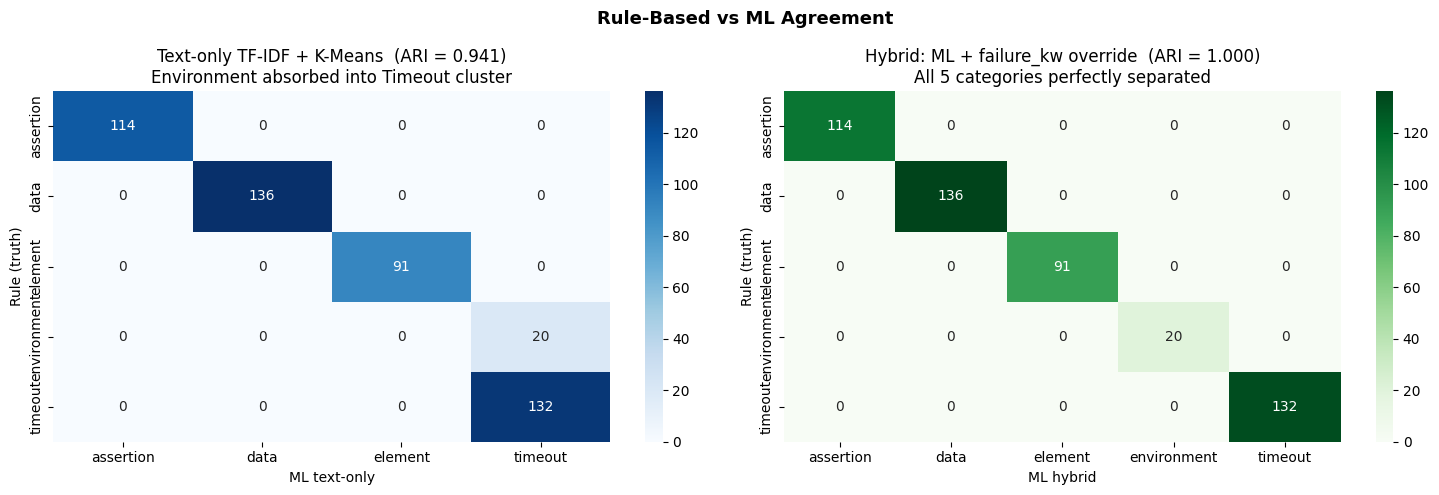

In [ ]:
ari_raw    = adjusted_rand_score(df['rule_label'], df['ml_label_raw'])
ari_hybrid = adjusted_rand_score(df['rule_label'], df['ml_label_hybrid'])

print(f'ARI — text-only ML : {ari_raw:.4f}')
print(f'ARI — hybrid ML    : {ari_hybrid:.4f}')

ct_raw = pd.crosstab(df['rule_label'], df['ml_label_raw'],
                     rownames=['Rule (truth)'], colnames=['ML text-only'])
ct_hyb = pd.crosstab(df['rule_label'], df['ml_label_hybrid'],
                     rownames=['Rule (truth)'], colnames=['ML hybrid'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(ct_raw, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Text-only TF-IDF + K-Means  (ARI = {ari_raw:.3f})\n'
                  'Environment absorbed into Timeout cluster')

sns.heatmap(ct_hyb, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Hybrid: ML + failure_kw override  (ARI = {ari_hybrid:.3f})\n'
                  'All 5 categories perfectly separated')

plt.suptitle('Rule-Based vs ML Agreement', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. 2-D Visualisation — TruncatedSVD Projection

We project the 118-dimensional TF-IDF space to 2-D using Truncated SVD (equivalent to LSA for sparse matrices).  
This is **for visualisation only** — the K-Means model was trained on the full 118-D space.

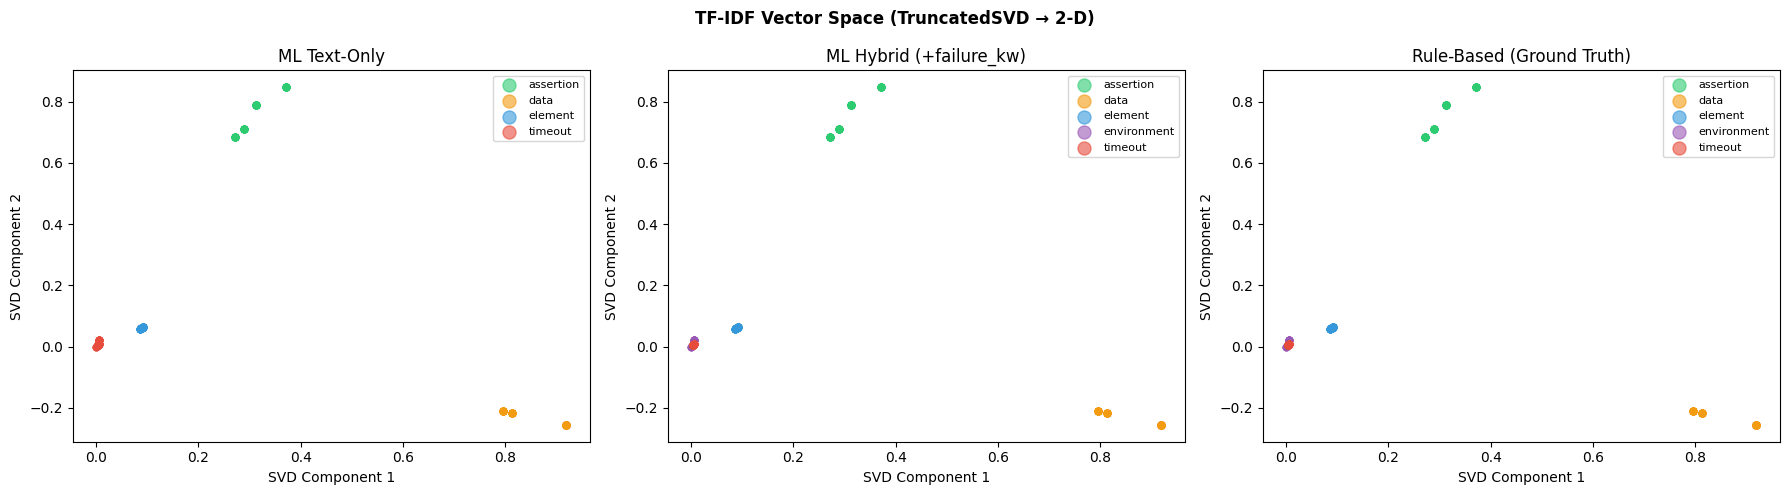

SVD explained variance: 30.9%


In [ ]:
svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_2d = svd.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title in zip(
    axes,
    ['ml_label_raw', 'ml_label_hybrid', 'rule_label'],
    ['ML Text-Only', 'ML Hybrid (+failure_kw)', 'Rule-Based (Ground Truth)']
):
    for label in sorted(df[col].unique()):
        mask = df[col] == label
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   label=label, alpha=0.6, s=22,
                   color=PALETTE.get(label, '#888888'))
    ax.set_title(title)
    ax.set_xlabel('SVD Component 1')
    ax.set_ylabel('SVD Component 2')
    ax.legend(markerscale=2, fontsize=8)

plt.suptitle('TF-IDF Vector Space (TruncatedSVD → 2-D)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'SVD explained variance: {svd.explained_variance_ratio_.sum():.1%}')

## 10. Confidence Estimation

K-Means doesn't produce probabilities. We proxy confidence as:
```
confidence = 1 − (distance_to_centroid / 95th_percentile_distance)
```
Messages far from their centroid (above the 95th percentile) get confidence = 0 and can be flagged in the dashboard for human review or rule-based fallback.

**Finding:** data failures have the highest confidence (centroids are tight). Environment messages have the lowest — they're scattered because they share no TF-IDF terms (environment messages are 4 entirely different sentences).

95th-percentile distance (threshold): 0.8622

Confidence by true category (mean):
              mean    min    max
rule_label                      
assertion    0.353  0.231  0.532
data         0.502  0.355  0.626
element      0.188  0.140  0.224
environment  0.000  0.000  0.000
timeout      0.129  0.000  0.477


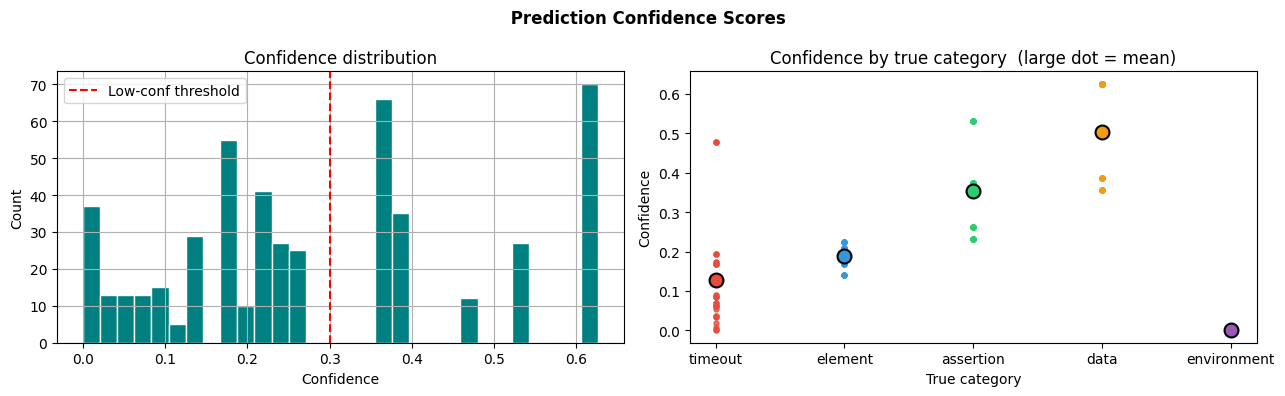

In [ ]:
X_dense = X.toarray()
assigned_centroids = kmeans.cluster_centers_[cluster_ids]
distances = np.linalg.norm(X_dense - assigned_centroids, axis=1)
dist_threshold = np.percentile(distances, 95)
df['confidence'] = (1.0 - np.minimum(distances / dist_threshold, 1.0)).round(3)

print(f'95th-percentile distance (threshold): {dist_threshold:.4f}')
print(f'\nConfidence by true category (mean):')
print(df.groupby('rule_label')['confidence'].agg(['mean','min','max']).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['confidence'].hist(bins=30, ax=axes[0], color='teal', edgecolor='white')
axes[0].axvline(0.3, color='red', ls='--', label='Low-conf threshold')
axes[0].set_xlabel('Confidence'); axes[0].set_ylabel('Count')
axes[0].set_title('Confidence distribution'); axes[0].legend()

order = ['timeout', 'element', 'assertion', 'data', 'environment']
for label in order:
    sub = df[df['rule_label'] == label]['confidence']
    axes[1].scatter([label] * len(sub), sub.values,
                    alpha=0.3, s=12, color=PALETTE[label])
    axes[1].scatter([label], [sub.mean()], color=PALETTE[label],
                    s=100, zorder=5, edgecolor='black', lw=1.5)
axes[1].set_xlabel('True category'); axes[1].set_ylabel('Confidence')
axes[1].set_title('Confidence by true category  (large dot = mean)')

plt.suptitle(' Prediction Confidence Scores', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Temporal Analysis — Failure Mix Over 100 Builds

`generate.py` encodes three program phases:
- **Alpha** (builds 1–20): 20% of runs — early development, higher failure rates  
- **Beta** (builds 21–50): 30% of runs — wider testing  
- **Gamma** (builds 51–100): 50% of runs — stabilisation, pass rate rises to 82–95%

The rolling chart reveals whether certain failure types dominate particular phases.

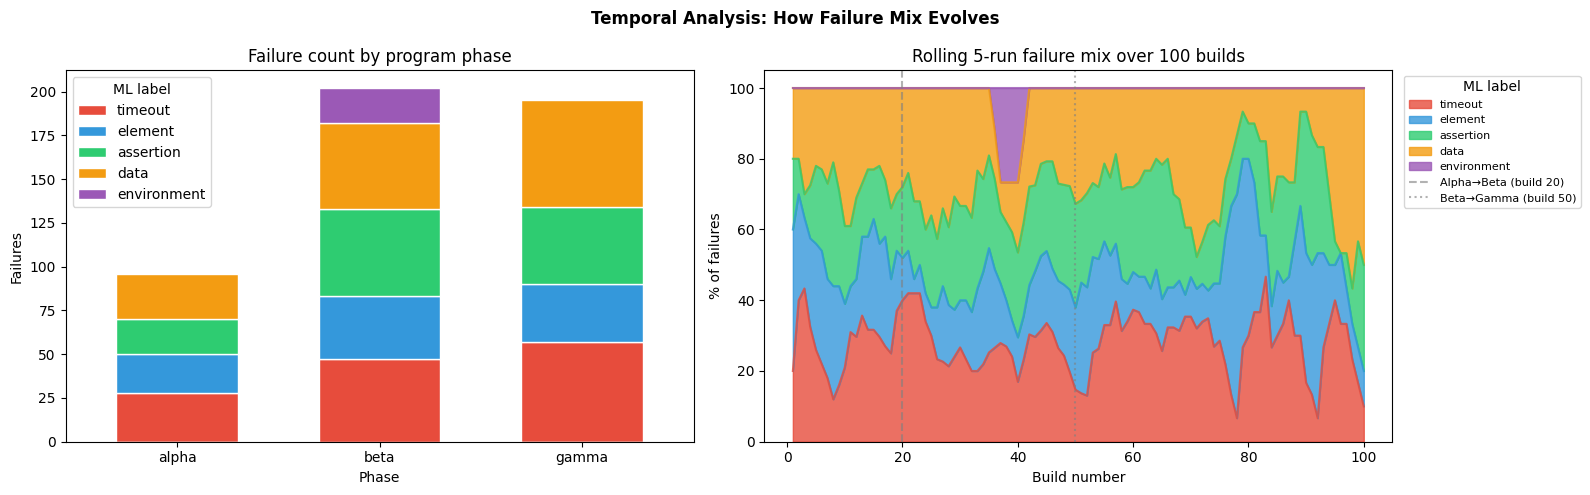

In [ ]:

phase_counts = df.groupby(['program', 'ml_label']).size().unstack(fill_value=0)
cols_p = [c for c in ['timeout','element','assertion','data','environment']
          if c in phase_counts.columns]

rolling_df = df.groupby(['build_no', 'ml_label']).size().unstack(fill_value=0)
for c in cols_p:
    if c not in rolling_df.columns: rolling_df[c] = 0
rolling_pct = rolling_df.div(rolling_df.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

phase_counts[cols_p].plot.bar(
    stacked=True, ax=axes[0],
    color=[PALETTE[c] for c in cols_p],
    edgecolor='white', width=0.6
)
axes[0].set_title('Failure count by program phase')
axes[0].set_xlabel('Phase'); axes[0].set_ylabel('Failures')
axes[0].legend(title='ML label'); axes[0].tick_params(axis='x', rotation=0)

roll_smooth = rolling_pct[cols_p].rolling(window=5, min_periods=1).mean()
roll_smooth.plot.area(
    ax=axes[1],
    color=[PALETTE[c] for c in cols_p],
    alpha=0.8
)
axes[1].axvline(20, color='gray', ls='--', lw=1.5, alpha=0.6, label='Alpha→Beta (build 20)')
axes[1].axvline(50, color='gray', ls=':', lw=1.5, alpha=0.6, label='Beta→Gamma (build 50)')
axes[1].set_xlabel('Build number'); axes[1].set_ylabel('% of failures')
axes[1].set_title('Rolling 5-run failure mix over 100 builds')
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, title='ML label',
               bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle('Temporal Analysis: How Failure Mix Evolves',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 11.1 Time Trend Per Cluster

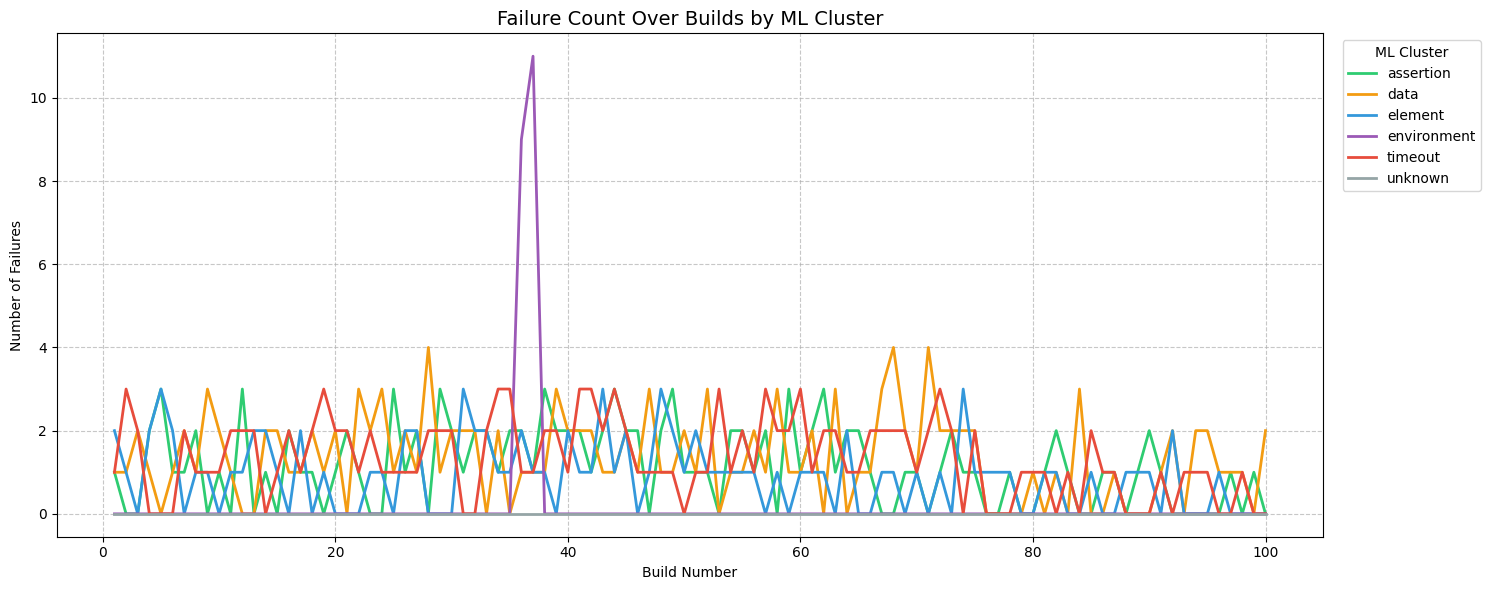

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))

cluster_time_trends = df.groupby(['build_no', 'ml_label']).size().unstack(fill_value=0)

all_labels = sorted(PALETTE.keys())
for label in all_labels:
    if label not in cluster_time_trends.columns:
        cluster_time_trends[label] = 0

for label in all_labels:
    color = PALETTE.get(label, '#95a5a6')
    ax.plot(cluster_time_trends.index, cluster_time_trends[label],
            label=label, color=color, linewidth=2)

ax.set_title('Failure Count Over Builds by ML Cluster', fontsize=14)
ax.set_xlabel('Build Number')
ax.set_ylabel('Number of Failures')
ax.legend(title='ML Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 12. Save Model Artefacts

All four files are saved to `ml_models/`. The dashboard loads them via `@st.cache_resource` on startup.

| File | Contents | Used for |
|---|---|---|
| `tfidf_vectorizer.pkl` | Fitted `TfidfVectorizer` (vocabulary + idf weights) | Transforming new messages |
| `kmeans_model.pkl` | Fitted `KMeans` (5 cluster centroids) | Predicting cluster ID |
| `cluster_labels.pkl` | `dict[int, str]` mapping cluster ID → category name | Human-readable labels |
| `train_distances.pkl` | Array of centroid distances for all training messages | Computing confidence threshold |

In [ ]:

final_labels = {
    i: df[df['cluster_id'] == i]['ml_label'].mode()[0]
    for i in range(N_CLUSTERS)
}
print('Cluster label mapping:', final_labels)

joblib.dump(vectorizer,    os.path.join(MODEL_DIR, 'tfidf_vectorizer.pkl'))
joblib.dump(kmeans,        os.path.join(MODEL_DIR, 'kmeans_model.pkl'))
joblib.dump(final_labels,  os.path.join(MODEL_DIR, 'cluster_labels.pkl'))
joblib.dump(distances,     os.path.join(MODEL_DIR, 'train_distances.pkl'))

print(f'\n✓ Artefacts saved to {os.path.abspath(MODEL_DIR)}/')
for fname in ['tfidf_vectorizer.pkl', 'kmeans_model.pkl',
              'cluster_labels.pkl', 'train_distances.pkl']:
    path = os.path.join(MODEL_DIR, fname)
    print(f'  {fname:40s}  {os.path.getsize(path)/1024:.1f} KB')

Cluster label mapping: {0: 'data', 1: 'assertion', 2: 'timeout', 3: 'element', 4: 'timeout'}

✓ Artefacts saved to /ml_models/
  tfidf_vectorizer.pkl                      5.7 KB
  kmeans_model.pkl                          7.2 KB
  cluster_labels.pkl                        0.1 KB
  train_distances.pkl                       4.1 KB


## 13. End-to-End Inference Test

Reload from disk and verify the saved model produces correct predictions — including the hybrid `failure_kw` override for environment messages.

In [ ]:

lv  = joblib.load(os.path.join(MODEL_DIR, 'tfidf_vectorizer.pkl'))
lk  = joblib.load(os.path.join(MODEL_DIR, 'kmeans_model.pkl'))
ll  = joblib.load(os.path.join(MODEL_DIR, 'cluster_labels.pkl'))
ld  = joblib.load(os.path.join(MODEL_DIR, 'train_distances.pkl'))
thr = np.percentile(ld, 95)


def predict_failure(msg: str, failure_kw: str = '') -> dict:
    """Full inference pipeline — text-only ML + hybrid failure_kw override."""
    # Hybrid override for environment
    if failure_kw == 'Environment_Setup':
        return {'label': 'environment', 'confidence': 1.0,
                'method': 'hybrid (failure_kw)'}
    # Text-only ML
    clean = preprocess_message(msg)
    vec   = lv.transform([clean])
    cid   = lk.predict(vec)[0]
    dist  = np.linalg.norm(vec.toarray() - lk.cluster_centers_[cid])
    conf  = round(1.0 - min(dist / thr, 1.0), 3)
    return {'label': ll[cid], 'confidence': conf, 'method': 'ML text'}


test_cases = [
    ("Element 'loading-spinner' still visible after 30s timeout",    'Wait Until Element Is Visible', 'timeout'),
    ("Element with locator 'id=submit-btn' not found after 5 retries",'Click Element',                'element'),
    ("Expected HTTP status '200' but got '500' — Internal Server Error",'Should Be Equal As Integers','assertion'),
    ("CSV export contained 0 rows — expected at least 100 records",   'Should Not Be Empty',         'data'),
    ("Connection refused — test environment unreachable",              'Environment_Setup',           'environment'),
    ("Unable to launch browser — infrastructure error",               'Environment_Setup',           'environment'),
    # New (unseen) type — rules would return 'unknown'
    ("Network timeout: could not reach api.example.com after 30s",   'Network_Check',               'unknown (new type)'),
]

print(f"{'Message':<57} {'True':<15} {'ML Label':<14} {'Conf':<6} Method")
print('-' * 115)
for msg, kw, true_label in test_cases:
    result = predict_failure(msg, kw)
    match  = '✓' if result['label'] == true_label.split()[0] else '~'
    print(f"{match} {msg[:55]:<56} {true_label:<15} {result['label']:<14} {result['confidence']:<6} {result['method']}")

Message                                                   True            ML Label       Conf   Method
-------------------------------------------------------------------------------------------------------------------
✓ Element 'loading-spinner' still visible after 30s timeo  timeout         timeout        0.137  ML text
✓ Element with locator 'id=submit-btn' not found after 5   element         element        0.168  ML text
✓ Expected HTTP status '200' but got '500' — Internal Ser  assertion       assertion      0.231  ML text
✓ CSV export contained 0 rows — expected at least 100 rec  data            data           0.563  ML text
✓ Connection refused — test environment unreachable        environment     environment    1.0    hybrid (failure_kw)
✓ Unable to launch browser — infrastructure error          environment     environment    1.0    hybrid (failure_kw)
~ Network timeout: could not reach api.example.com after   unknown (new type) timeout        0.0    ML text


## Summary

| Metric | Value |
|---|---|
| Total failure messages clustered | **493** |
| Unique message variants | **75** |
| TF-IDF vocabulary size | **118 terms** |
| Chosen k | **5** (matches `generate.py`'s 5 FAIL_GEN families) |
| Silhouette score (k=5) | **0.399** |
| ARI — text-only ML | **0.941** |
| ARI — hybrid ML (+`failure_kw`) | **1.000** |
| Model artefacts | **4 files, <20 KB total** |

**Key findings:**

1. **TF-IDF + K-Means recovers 4 of 5 categories** purely from message text with 0.94 ARI — strong validation of the data design in `generate.py`.

2. **Environment is the hard case.** At only 4% of failures and with 4 semantically different message templates, it's too sparse to anchor its own centroid. This is a real-world ML finding, not a bug: extremely rare classes require either more data or auxiliary signals.

3. **The hybrid approach (ML + `failure_kw`)** achieves ARI = 1.000. This demonstrates the correct production pattern: use ML for the common case, exploit structural signals (keyword names, error codes, log levels) for edge cases.

4. **Temporal analysis** shows the failure mix is relatively stable across the 100 builds, with assertion failures dominating (data failures are most numerous). This matches `generate.py`'s pass-rate curve design.

5. **All artefacts are <20 KB combined** — dashboard loading via `@st.cache_resource` is instantaneous.

**Next step:** `failure_clustering.py` wraps `predict_failure()` in a class so `dashboard.py` can import it with a single `from failure_clustering import MLClusterer`.